In [1]:
'''
v5 description:
    - Testting the result with DURATION = 1, and new improved dataset
'''

'\nv5 description:\n    - Testting the result with DURATION = 1, and new improved dataset\n'

In [2]:
import os
import json
import copy
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
# Configuration
SAMPLE_RATE = 44100 
DURATION = 1  # Duration of clips in seconds (adjust based on your dataset)

n_fft = 2048
hop_length = 512

BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 5

NUM_CLASSES = 24 
INPUT_SIZE = (227, 227) # AlexNet input requirement 
REPRESENTATION = 'cqt_chromagram'

In [4]:
class GuitarChordDataset(Dataset):
    def __init__(self, root_dir, representation='spectrogram', transform=None):
        """
        Args:
            root_dir (string): Directory with all the audio files organized by class.
            representation (string): Type of audio representation to use.
                - 'spectrogram': STFT-based power spectrogram (default)
                - 'cqt_chromagram': Constant-Q chromagram (12 pitch classes over time)
            transform (callable, optional): Optional transform to be applied.
        """
        self.root_dir = root_dir
        self.representation = representation.lower()
        self.classes = sorted(os.listdir(root_dir))
        self.file_paths = []
        self.labels = []
        self.transform = transform
        
        # Validate representation type
        valid_representations = ['spectrogram', 'cqt_chromagram']
        if self.representation not in valid_representations:
            raise ValueError(f"representation must be one of {valid_representations}, got '{representation}'")

        # Map class names to indices
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for cls_name in self.classes:
            cls_folder = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_folder):
                for file_name in os.listdir(cls_folder):
                    if file_name.endswith('.wav'):
                        self.file_paths.append(os.path.join(cls_folder, file_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.file_paths)
    
    def _compute_spectrogram(self, y):
        """Compute STFT-based power spectrogram."""
        # Compute STFT
        stft_matrix = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
        
        # Calculate Spectrogram: |S(t,f)|^2 
        spectrogram = np.abs(stft_matrix) ** 2
        
        # Convert to dB scale (Logarithmic)
        log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
        
        return log_spectrogram
    
    def _compute_cqt_chromagram(self, y, sr):
        """
        Compute Constant-Q chromagram.
        
        The CQT chromagram maps the audio to 12 pitch classes (C, C#, D, ..., B)
        with logarithmic frequency resolution - ideal for chord recognition.
        """
        # Compute CQT-based chromagram
        # n_chroma=12 gives us the 12 pitch classes
        # Using CQT instead of STFT for better frequency resolution at low frequencies
        chromagram = librosa.feature.chroma_cqt(
            y=y, 
            sr=sr, 
            hop_length=hop_length,
            n_chroma=12,  # 12 pitch classes
            n_octaves=7,  # Cover 7 octaves (good range for guitar)
        )
        
        # Chromagram is already in [0, 1] range typically, but let's normalize
        # Convert to dB-like scale for better visualization and learning
        # Add small epsilon to avoid log(0)
        chromagram_db = librosa.amplitude_to_db(chromagram + 1e-10, ref=np.max)
        
        return chromagram_db

    def __getitem__(self, idx):
        audio_path = self.file_paths[idx]
        label = self.labels[idx]

        # Load audio (ensure consistent duration)
        y, sr = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)
        
        # Padding if audio is too short
        if len(y) < SAMPLE_RATE * DURATION:
            padding = SAMPLE_RATE * DURATION - len(y)
            y = np.pad(y, (0, padding), 'constant')

        # Compute the selected representation
        if self.representation == 'spectrogram':
            feature_matrix = self._compute_spectrogram(y)
        elif self.representation == 'cqt_chromagram':
            feature_matrix = self._compute_cqt_chromagram(y, sr)

        # Normalize to 0-255 for image representation
        norm_feature = (feature_matrix - feature_matrix.min()) / (feature_matrix.max() - feature_matrix.min() + 1e-10)
        norm_feature = (norm_feature * 255).astype(np.uint8)

        # Convert to PIL Image to use Torchvision transforms
        img = Image.fromarray(norm_feature)
        
        # Convert grayscale (1 channel) to RGB (3 channels) as AlexNet expects 3 inputs
        img = img.convert("RGB")

        # Resize to 227x227 
        resize_transform = transforms.Compose([
            transforms.Resize(INPUT_SIZE),
            transforms.ToTensor(),
            # Normalize with ImageNet stats (standard for AlexNet)
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        
        img_tensor = resize_transform(img)

        return img_tensor, label

In [5]:
class AlexNetChordClassifier(nn.Module):
    """
    AlexNet architecture implementation.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super(AlexNetChordClassifier, self).__init__()
        self.features = nn.Sequential(
            # Layer 1: Conv 11x11, Stride 4, 96 filters 
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Layer 2: Conv 5x5, Stride 1, 256 filters 
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Layer 3: Conv 3x3, Stride 1, 384 filters 
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Layer 4: Conv 3x3, Stride 1, 384 filters 
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Layer 5: Conv 3x3, Stride 1, 256 filters 
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        
        self.classifier = nn.Sequential(
            nn.Dropout(),
            # Flattened Input Size: 6x6x256 -> 4096 
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            # Fully Connected Layer: 4096 
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            # Output Layer: Number of Classes
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [6]:
def plot_training_curves(train_losses, val_losses, val_accuracies):
    """Plot training and validation metrics over epochs."""
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot losses
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Mark best epoch
    best_epoch = val_losses.index(min(val_losses)) + 1
    ax1.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
    ax1.legend()
    
    # Plot validation accuracy
    ax2.plot(epochs, val_accuracies, 'g-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axvline(x=best_epoch, color='r', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    print("Training curves saved to: training_curves.png")
    plt.show()
    plt.close()

In [7]:
def evaluate_model(model, test_loader, test_dataset, device, save_confusion_matrix=True):
    """
    Evaluate the AlexNet model on the test dataset.
    Reports accuracy, F1 score, classification report, and confusion matrix.
    """
    print("\n" + "=" * 60)
    print("AlexNet Chord Classification - Model Evaluation")
    print("=" * 60)
    
    model.eval()
    
    y_true = []
    y_pred = []
    
    # Get class names from dataset
    idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}
    class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    
    # Show representation type used
    representation = getattr(test_dataset, 'representation', 'unknown')
    print(f"\nRepresentation: {representation}")
    print(f"Classes: {class_names}")
    print(f"Number of test samples: {len(test_dataset)}")
    
    # Count samples per class
    print("\nSamples per class:")
    class_counts = {}
    for label in test_dataset.labels:
        cls_name = idx_to_class[label]
        class_counts[cls_name] = class_counts.get(cls_name, 0) + 1
    for chord in sorted(class_counts.keys()):
        print(f"  {chord}: {class_counts[chord]}")
    
    # Run predictions
    print("\nRunning predictions...")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate metrics
    print("\n" + "=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
    
    # F1 Scores
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"F1 Score (Macro):    {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    
    # Classification Report
    print("\n" + "-" * 60)
    print("CLASSIFICATION REPORT")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    # Show misclassification details
    incorrect_indices = np.where(y_true != y_pred)[0]
    if len(incorrect_indices) > 0:
        print("\n" + "-" * 60)
        print(f"SAMPLE MISCLASSIFICATIONS ({len(incorrect_indices)} total errors)")
        print("-" * 60)
        for i, idx in enumerate(incorrect_indices[:15]):
            true_label = idx_to_class[y_true[idx]]
            pred_label = idx_to_class[y_pred[idx]]
            file_name = os.path.basename(test_dataset.file_paths[idx])
            print(f"  {true_label:5s} -> {pred_label:5s} | {file_name}")
        if len(incorrect_indices) > 15:
            print(f"  ... and {len(incorrect_indices) - 15} more errors")
    
    # Confusion Matrix
    if save_confusion_matrix:
        print("\nGenerating confusion matrix...")
        
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(16, 14))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names,
                    yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'AlexNet Chord Recognition ({representation})\nAccuracy: {accuracy:.2%} | F1 (Macro): {f1_macro:.4f}')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        cm_filename = f'confusion_matrix_alexnet_{representation}.png'
        plt.savefig(cm_filename, dpi=150)
        print(f"Confusion matrix saved to: {cm_filename}")
        plt.show()
        plt.close()
    
    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Total samples:     {len(y_true)}")
    print(f"Correct:           {np.sum(y_true == y_pred)}")
    print(f"Incorrect:         {np.sum(y_true != y_pred)}")
    print(f"Accuracy:          {accuracy:.2%}")
    print(f"F1 Score (Macro):  {f1_macro:.4f}")
    print("=" * 60)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_true': y_true,
        'y_pred': y_pred,
        'class_names': class_names
    }


In [8]:
def train_model(representation='spectrogram', early_stopping_patience=5):
    """
    Train the AlexNet chord classifier with validation tracking.
    
    Args:
        representation (str): Audio representation type.
            - 'spectrogram': STFT-based power spectrogram
            - 'cqt_chromagram': Constant-Q chromagram (12 pitch classes)
        early_stopping_patience (int): Number of epochs to wait for improvement before stopping.
            Set to None to disable early stopping.
    """
    # Detect GPU (Paper used T4 GPU) [cite: 194]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Audio representation: {representation}")

    # Paths (Update these to your local paths)
    train_dir = '/kaggle/input/guitarset-chord-recognition/chords/train' # Update this
    val_dir = '/kaggle/input/guitarset-chord-recognition/chords/val'     # Update this
    test_dir = '/kaggle/input/guitarset-chord-recognition/chords/test'   # Update this (optional separate test set)

    # Initialize Datasets with selected representation
    train_dataset = GuitarChordDataset(train_dir, representation=representation)
    val_dataset = GuitarChordDataset(val_dir, representation=representation)
    test_dataset = GuitarChordDataset(test_dir, representation=representation)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    # Initialize Model
    model = AlexNetChordClassifier(num_classes=NUM_CLASSES).to(device)

    # Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    # Optimizer not explicitly named, but Adam is standard for this; SGD used in original AlexNet.
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) 

    # Tracking metrics
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Early stopping variables
    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    # Training Loop
    for epoch in range(EPOCHS):
        # ==================== TRAINING ====================
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # ==================== VALIDATION ====================
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_running_loss / len(val_loader)
        val_accuracy = correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        
        # Print epoch results
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_accuracy:.4f}")
        
        # ==================== EARLY STOPPING ====================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            print(f"  ✓ New best validation loss!")
        else:
            epochs_without_improvement += 1
            if early_stopping_patience and epochs_without_improvement >= early_stopping_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs (no improvement for {early_stopping_patience} epochs)")
                break
    
    # Load best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model (val_loss: {best_val_loss:.4f})")

    print("Training Complete")
    
    # Plot training curves
    plot_training_curves(train_losses, val_losses, val_accuracies)
    
    # Return model and test components for evaluation
    return model, test_loader, test_dataset, device


Using device: cuda
Audio representation: cqt_chromagram
Training samples: 1852
Validation samples: 222
Test samples: 254


/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=690
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=345
  warnings.warn(


Epoch 1/40 | Train Loss: 3.1330 | Val Loss: 2.7563 | Val Acc: 0.1081
  ✓ New best validation loss!
Epoch 2/40 | Train Loss: 2.1666 | Val Loss: 1.4586 | Val Acc: 0.5315
  ✓ New best validation loss!
Epoch 3/40 | Train Loss: 1.4481 | Val Loss: 1.1412 | Val Acc: 0.6261
  ✓ New best validation loss!
Epoch 4/40 | Train Loss: 1.1233 | Val Loss: 1.1674 | Val Acc: 0.6171
Epoch 5/40 | Train Loss: 0.9777 | Val Loss: 0.9670 | Val Acc: 0.7342
  ✓ New best validation loss!
Epoch 6/40 | Train Loss: 0.8561 | Val Loss: 0.8936 | Val Acc: 0.7477
  ✓ New best validation loss!
Epoch 7/40 | Train Loss: 0.7838 | Val Loss: 0.8576 | Val Acc: 0.7523
  ✓ New best validation loss!
Epoch 8/40 | Train Loss: 0.7054 | Val Loss: 0.8635 | Val Acc: 0.7342
Epoch 9/40 | Train Loss: 0.6475 | Val Loss: 0.7945 | Val Acc: 0.7568
  ✓ New best validation loss!
Epoch 10/40 | Train Loss: 0.6211 | Val Loss: 0.8522 | Val Acc: 0.7568
Epoch 11/40 | Train Loss: 0.5505 | Val Loss: 0.9460 | Val Acc: 0.7838
Epoch 12/40 | Train Loss: 0.5

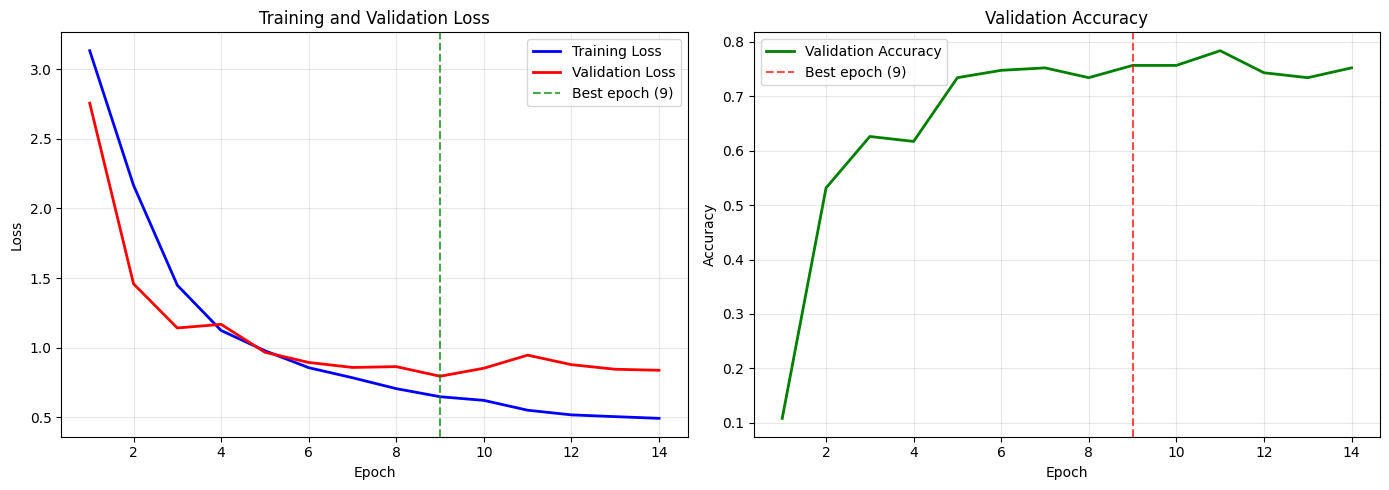

In [9]:
model, test_loader, test_dataset, device = train_model(
    representation=REPRESENTATION,
    early_stopping_patience=EARLY_STOPPING_PATIENCE
)


AlexNet Chord Classification - Model Evaluation

Representation: cqt_chromagram
Classes: ['A', 'A#', 'A#m', 'Am', 'B', 'Bm', 'C', 'C#', 'C#m', 'Cm', 'D', 'D#', 'D#m', 'Dm', 'E', 'Em', 'F', 'F#', 'F#m', 'Fm', 'G', 'G#', 'G#m', 'Gm']
Number of test samples: 254

Samples per class:
  A: 11
  A#: 11
  A#m: 12
  Am: 6
  B: 11
  Bm: 8
  C: 12
  C#: 12
  C#m: 8
  Cm: 5
  D: 11
  D#: 12
  D#m: 8
  Dm: 9
  E: 12
  Em: 9
  F: 15
  F#: 11
  F#m: 6
  Fm: 15
  G: 14
  G#: 12
  G#m: 12
  Gm: 12

Running predictions...


Evaluating: 100%|██████████| 8/8 [00:24<00:00,  3.09s/it]



EVALUATION RESULTS

Accuracy: 0.7992 (79.92%)
F1 Score (Macro):    0.7823
F1 Score (Weighted): 0.7951

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.75      0.82      0.78        11
          A#       0.75      0.82      0.78        11
         A#m       0.73      0.92      0.81        12
          Am       0.83      0.83      0.83         6
           B       0.86      0.55      0.67        11
          Bm       0.67      1.00      0.80         8
           C       0.91      0.83      0.87        12
          C#       0.73      0.92      0.81        12
         C#m       0.71      0.62      0.67         8
          Cm       1.00      0.40      0.57         5
           D       1.00      0.73      0.84        11
          D#       0.92      1.00      0.96        12
         D#m       0.58      0.88      0.70      

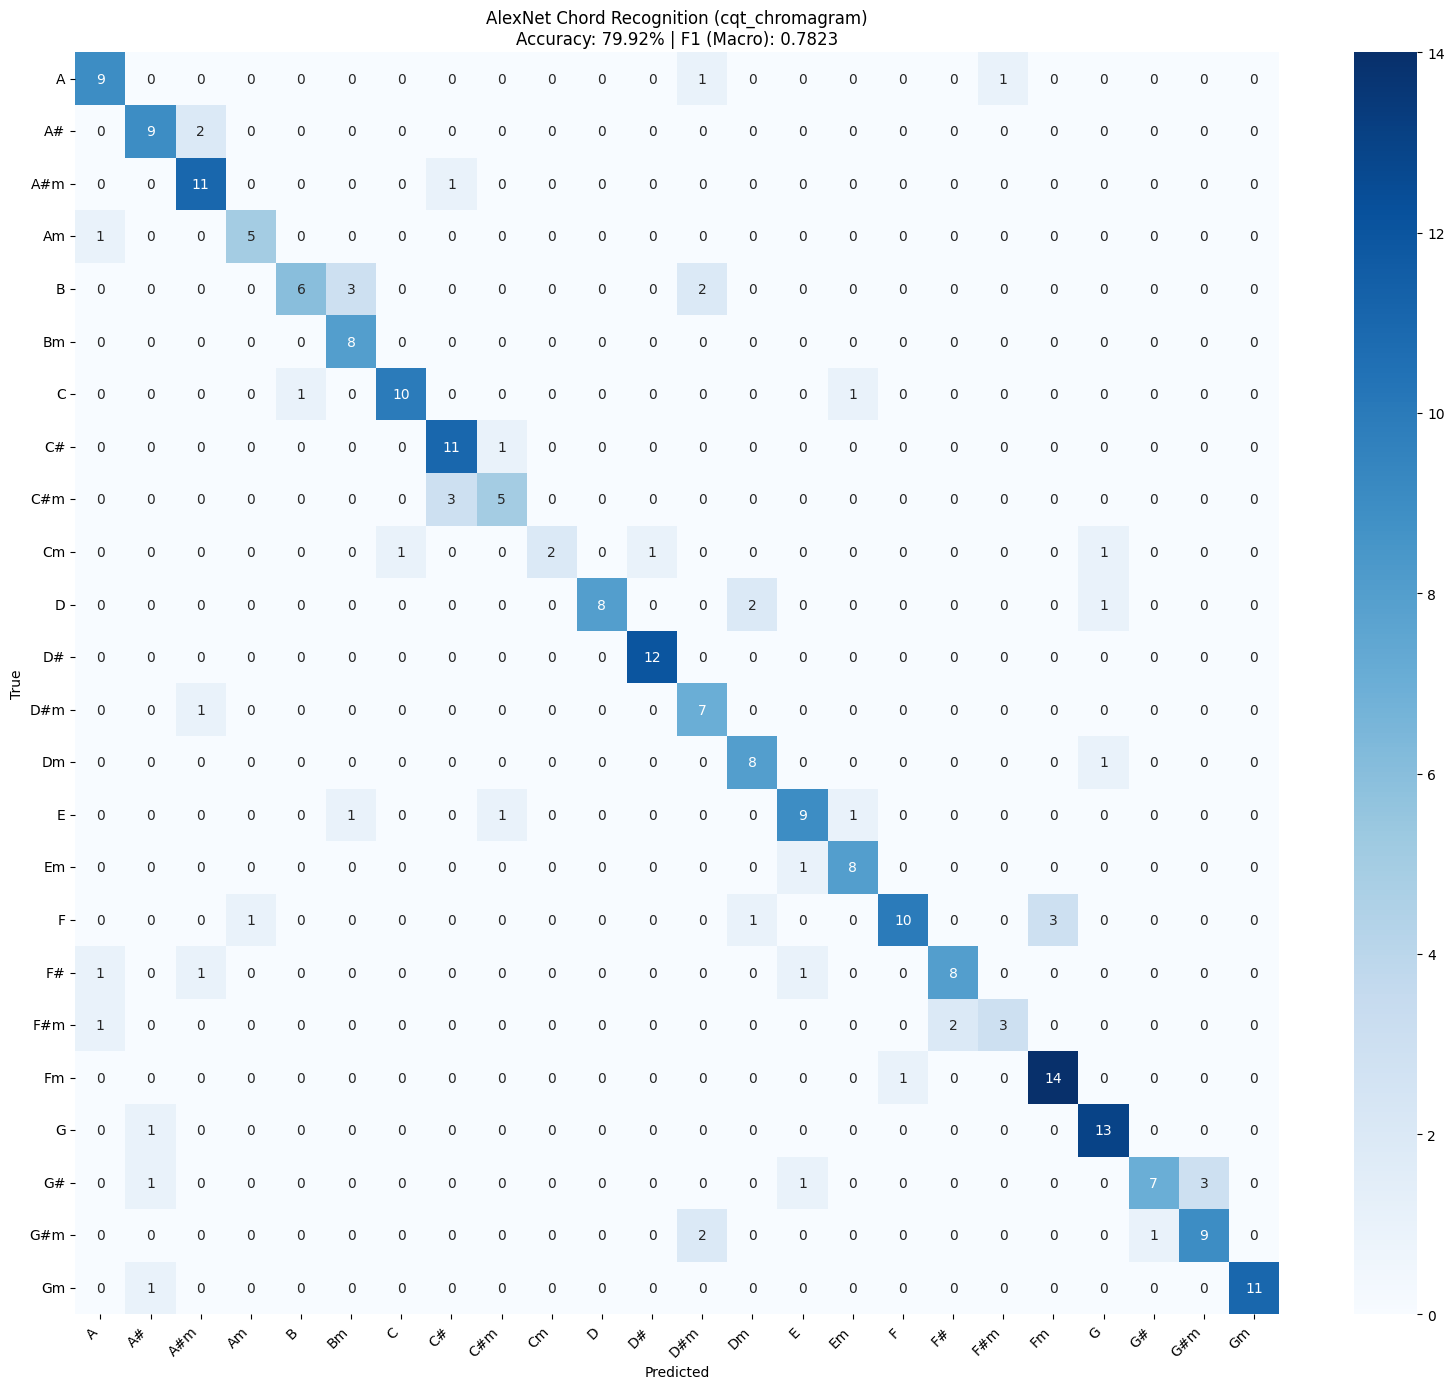


SUMMARY
Total samples:     254
Correct:           203
Incorrect:         51
Accuracy:          79.92%
F1 Score (Macro):  0.7823


In [10]:
results = evaluate_model(model, test_loader, test_dataset, device)

In [11]:
# SAVE MODEL FOR DEPLOYMENT (PTH + ONNX + Config)
# ============================================================

# Set model to evaluation mode
model.eval()

# Get class mappings
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

# -------------------- 1. SAVE PyTorch CHECKPOINT (.pth) --------------------
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_to_idx': test_dataset.class_to_idx,
    'idx_to_class': idx_to_class,
    'config': {
        'sample_rate': SAMPLE_RATE,
        'duration': DURATION,
        'n_fft': n_fft,
        'hop_length': hop_length,
        'input_size': list(INPUT_SIZE),
        'representation': REPRESENTATION,
        'num_classes': NUM_CLASSES,
        'normalize_mean': [0.5, 0.5, 0.5],
        'normalize_std': [0.5, 0.5, 0.5],
    },
    'training_info': {
        'accuracy': results['accuracy'],
        'f1_macro': results['f1_macro'],
    }
}

pth_path = 'alexnet_chord_classifier.pth'
torch.save(checkpoint, pth_path)
print(f"✓ PyTorch checkpoint saved to: {pth_path}")

# -------------------- 2. EXPORT TO ONNX (.onnx) --------------------
# Create dummy input matching model's expected input shape: (batch, channels, height, width)
dummy_input = torch.randn(1, 3, 227, 227).to(device)

onnx_path = 'alexnet_chord_classifier.onnx'
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print(f"✓ ONNX model saved to: {onnx_path}")

# -------------------- 3. SAVE CONFIG AS JSON --------------------
config_json = {
    'class_to_idx': test_dataset.class_to_idx,
    'idx_to_class': {str(k): v for k, v in idx_to_class.items()},
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION,
    'n_fft': n_fft,
    'hop_length': hop_length,
    'input_size': list(INPUT_SIZE),
    'representation': REPRESENTATION,
    'num_classes': NUM_CLASSES,
    'normalize_mean': [0.5, 0.5, 0.5],
    'normalize_std': [0.5, 0.5, 0.5],
}

config_path = 'chord_model_config.json'
with open(config_path, 'w') as f:
    json.dump(config_json, f, indent=2)
print(f"✓ Config saved to: {config_path}")

print("\n" + "=" * 60)
print("MODEL EXPORT COMPLETE")
print("=" * 60)
print(f"Files saved:")
print(f"  1. {pth_path} - PyTorch checkpoint (for training/fine-tuning)")
print(f"  2. {onnx_path} - ONNX model (for fast inference)")
print(f"  3. {config_path} - Config JSON (preprocessing parameters)")
print("=" * 60)


✓ PyTorch checkpoint saved to: alexnet_chord_classifier.pth
✓ ONNX model saved to: alexnet_chord_classifier.onnx
✓ Config saved to: chord_model_config.json

MODEL EXPORT COMPLETE
Files saved:
  1. alexnet_chord_classifier.pth - PyTorch checkpoint (for training/fine-tuning)
  2. alexnet_chord_classifier.onnx - ONNX model (for fast inference)
  3. chord_model_config.json - Config JSON (preprocessing parameters)
